#1. Datenimport

In [16]:
import pandas as pd
import numpy as np

# Dateien aus CSV laden direkt aus dem lokalen Verzeichnis des Notebooks.
df = pd.read_csv('volume_flow_data.csv')

# Konvertierung des Zeitstempels für die zeitliche Analyse
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# Anzeige der geladenen Daten zur Verifizierung
print("Daten erfolgreich geladen:")
df.head()

Daten erfolgreich geladen:


,Timestamp,Volume Flow (m^3/h)
0,2024-04-01 00:00:00,312.54
1,2024-04-01 00:01:00,193.78
2,2024-04-01 00:02:00,393.96
3,2024-04-01 00:03:00,364.70
4,2024-04-01 00:04:00,100.33


#2. Modellierung der Pumpenkennlinie

In [17]:
# Definition der Stützpunkte für das Laufrad 269mm (Werte aus KSB-Datenblatt)
Q_punkte = np.array([0, 200, 400, 600])
P_punkte = np.array([12, 17, 22, 25])

# Approximation der Leistungskennlinie durch ein Polynom 2. Grades
fit_coeff = np.polyfit(Q_punkte, P_punkte, 2)
P_funktion = np.poly1d(fit_coeff)

# Berechnung der momentanen Leistungsaufnahme für jeden Betriebspunkt der Messreihe
df['Power_kW'] = P_funktion(df['Volume Flow (m^3/h)'])

#3. Berechnung von Energie & Wirkungsgrad

In [18]:
# --- 1. Physikalische Berechnungen ---
rho = 1033    # Dichte in kg/m^3
g = 9.81      # Erdbeschleunigung in m/s^2
H = 20        # Förderhöhe in m

# Energieberechnung
df['Energy_kWh'] = df['Power_kW'] * (1/60)

# Hydraulische Leistung & Wirkungsgrad
df['P_hyd_kW'] = (rho * g * H * (df['Volume Flow (m^3/h)'] / 3600)) / 1000
df['Efficiency'] = df['P_hyd_kW'] / df['Power_kW']

# Ungenutzte Energie
df['Unused_Energy_kWh'] = (df['Power_kW'] - df['P_hyd_kW']) * (1/60)

# Variablen für die Ausgabe zuweisen
energy_total = df['Energy_kWh'].sum()
efficiency_avg = df['Efficiency'].mean() * 100
energy_unused = df['Unused_Energy_kWh'].sum()

# Ausgabe
print("ERGEBNISSE:")
print("-" * 38)
print(f"{'Gesamtenergie:':<25} {energy_total:>8.2f} kWh")
print(f"{'Mittl. Wirkungsgrad:':<27} {efficiency_avg:>8.2f} %")
print(f"{'Ungenutzte Energie:':<25} {energy_unused:>8.2f} kWh")
print("-" * 38)

ERGEBNISSE:
--------------------------------------
Gesamtenergie:              443.45 kWh
Mittl. Wirkungsgrad:           75.15 %
Ungenutzte Energie:         101.08 kWh
--------------------------------------


#4. Visualisierung der Ergebnisse

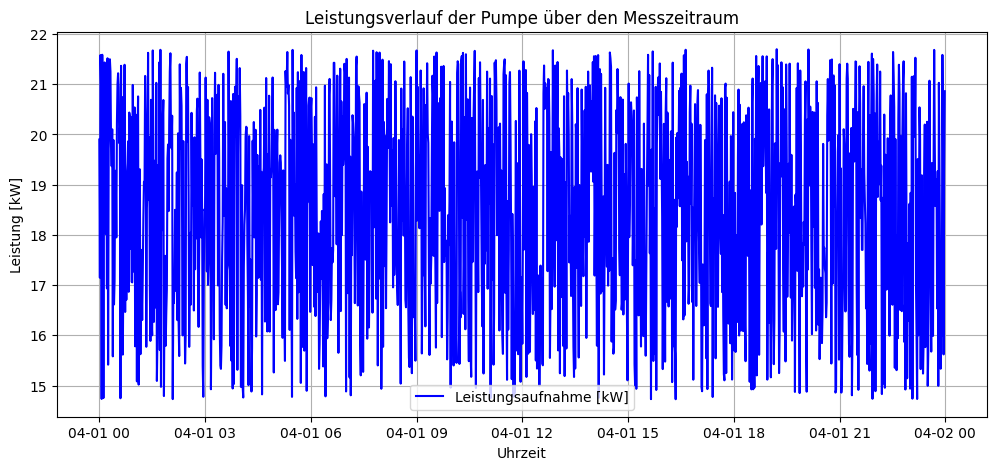

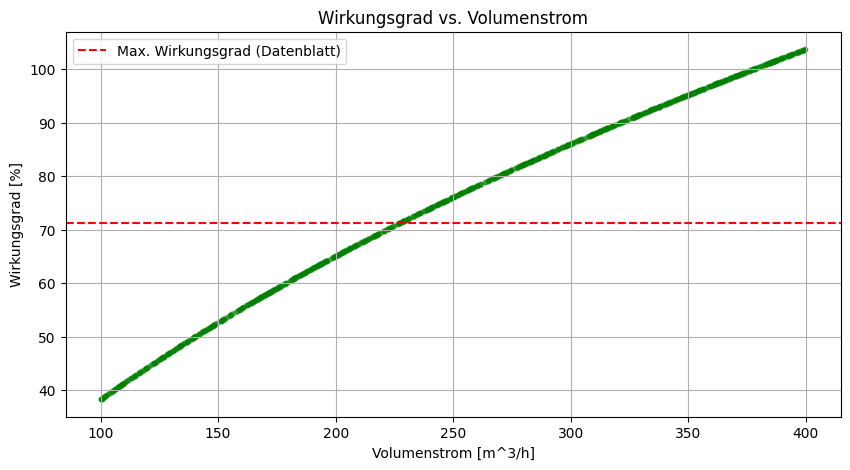

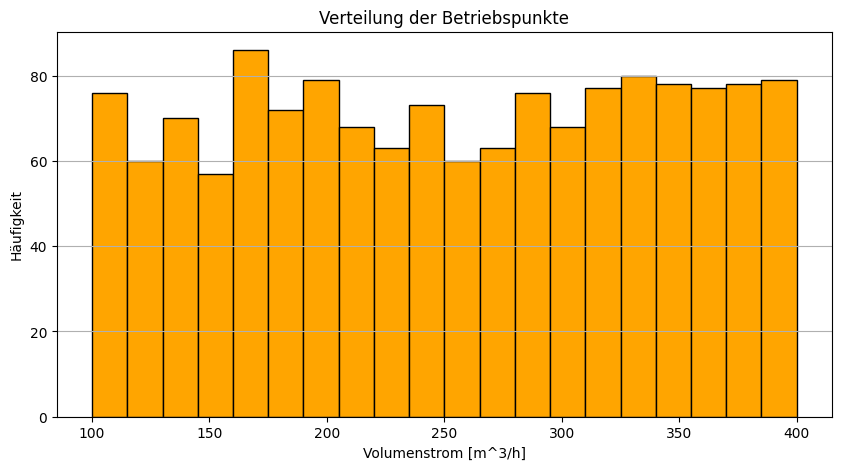

In [19]:
import matplotlib.pyplot as plt

# Plot 1: Leistungsverlauf über den Messzeitraum
plt.figure(figsize=(12, 5))
plt.plot(df['Timestamp'], df['Power_kW'], label='Leistungsaufnahme [kW]', color='blue')
plt.title('Leistungsverlauf der Pumpe über den Messzeitraum')
plt.xlabel('Uhrzeit')
plt.ylabel('Leistung [kW]')
plt.grid(True)
plt.legend()
plt.show()

# Plot 2: Wirkungsgrad in Abhängigkeit vom Volumenstrom
plt.figure(figsize=(10, 5))
plt.scatter(df['Volume Flow (m^3/h)'], df['Efficiency'] * 100, alpha=0.3, s=10, color='green')
plt.axhline(y=71.3, color='r', linestyle='--', label='Max. Wirkungsgrad (Datenblatt)')
plt.title('Wirkungsgrad vs. Volumenstrom')
plt.xlabel('Volumenstrom [m^3/h]')
plt.ylabel('Wirkungsgrad [%]')
plt.legend()
plt.grid(True)
plt.show()

# Plot 3: Histogramm welcher Volumenstrom wurde wie oft angefahren
plt.figure(figsize=(10, 5))
plt.hist(df['Volume Flow (m^3/h)'], bins=20, color='orange', edgecolor='black')
plt.title('Verteilung der Betriebspunkte')
plt.xlabel('Volumenstrom [m^3/h]')
plt.ylabel('Häufigkeit')
plt.grid(axis='y')
plt.show()